In [1]:
# Notebook cell: add project root to sys.path so `src` package can be imported
import sys
from pathlib import Path

# If notebook sits in data/ (as yours does), this finds the repo root automatically:
p = Path.cwd()
# walk up until a folder containing "src" is found (or stop at filesystem root)
while p != p.parent and not (p / "src").exists():
    p = p.parent

proj_root = p
print("Using project root:", proj_root)
sys.path.insert(0, str(proj_root))

Using project root: /Users/martinschmauch/Code/TUMCode/MasterThesis


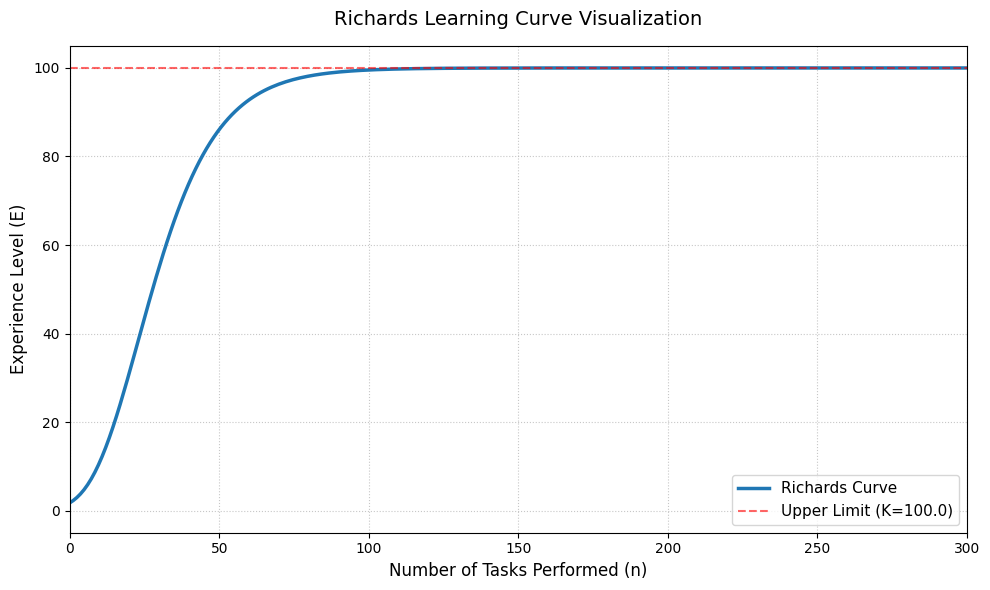

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the parameters from your thesis model
A = 0.0      # Lower asymptote
K = 100.0    # Upper asymptote
v = 0.07    # Growth rate
Q = 0.5 # Inflection point modifier
M = 0.1      # Shape parameter

# 2. Define the Richards Curve function using numpy for array operations
def richards_curve(n, A, K, v, Q, M):
    return A + (K - A) / (1 + Q * np.exp(-v * n))**(1/M)

# 3. Generate data points
# We simulate 0 to 300 tasks (250 evenly spaced points for a smooth line)
n_values = np.linspace(0, 300, 250)
e_values = richards_curve(n_values, A, K, v, Q, M)

# 4. Create an academic-style plot
plt.figure(figsize=(10, 6))
plt.plot(n_values, e_values, color='#1f77b4', linewidth=2.5, label='Richards Curve')

# Add visual markers for the asymptotes
plt.axhline(y=K, color='red', linestyle='--', alpha=0.6, label=f'Upper Limit (K={K})')
if A > 0:
    plt.axhline(y=A, color='gray', linestyle='--', alpha=0.6, label=f'Lower Limit (A={A})')

# Formatting the plot
plt.title('Richards Learning Curve Visualization', fontsize=14, pad=15)
plt.xlabel('Number of Tasks Performed (n)', fontsize=12)
plt.ylabel('Experience Level (E)', fontsize=12)

# Set axis limits to give the line some breathing room
plt.xlim(0, 300)
plt.ylim(A - 5, K + 5)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11, loc='lower right')

# Display the plot
plt.tight_layout()
plt.show()

In [3]:
"""
Visualize pickled process model with branching probabilities.
Supports both the legacy logistic model and the simplified transition model.
"""
import pickle
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

sys.path.append('.')
from src.process.model import ProbabilisticProcessModel


def load_process_model() -> ProbabilisticProcessModel:
    """Load pickled process model."""
    pkl = Path(proj_root / "data/process_model.pkl")
    with pkl.open("rb") as f:
        model = pickle.load(f)
    return model


def _is_simple_transition_model(model: ProbabilisticProcessModel) -> bool:
    """Detect simplified model format: source_activity -> {dest_activity: probability}."""
    if not model.transition_models:
        return False
    return any(isinstance(v, dict) for v in model.transition_models.values())


def _collect_simple_edges(model: ProbabilisticProcessModel):
    """Collect (src, dst, prob) edges from simplified transition dicts."""
    edges = []
    for src, dst_map in model.transition_models.items():
        if not isinstance(dst_map, dict):
            continue
        for dst, prob in dst_map.items():
            try:
                p = float(prob)
            except (TypeError, ValueError):
                continue
            if p > 0:
                edges.append((src, dst, p))
    return edges


def _add_end_edges_for_selected_nodes(model: ProbabilisticProcessModel, selected_nodes: set):
    """Create explicit transitions to __END__ for nodes that may terminate a case."""
    end_edges = []
    for node in selected_nodes:
        if node in {"__START__", "__END__"}:
            continue

        outgoing = model.transition_models.get(node)
        if isinstance(outgoing, dict):
            total_out = 0.0
            for _, prob in outgoing.items():
                try:
                    total_out += float(prob)
                except (TypeError, ValueError):
                    continue
            residual = max(0.0, 1.0 - total_out)
            if residual > 1e-9:
                end_edges.append((node, "__END__", residual))
        else:
            # No explicit outgoing map means termination after this activity.
            end_edges.append((node, "__END__", 1.0))
    return end_edges


def _edge_colors_by_weight(weights: np.ndarray):
    """Map low weights to strong red and high weights to strong blue."""
    if len(weights) == 0:
        return []

    min_w = float(weights.min())
    max_w = float(weights.max())

    low_rgb = np.array([220, 20, 60], dtype=float) / 255.0    # crimson (low probability)
    high_rgb = np.array([0, 78, 152], dtype=float) / 255.0    # strong blue (high probability)

    if max_w - min_w < 1e-12:
        return [tuple(high_rgb) for _ in weights]

    norm = (weights - min_w) / (max_w - min_w)
    colors = [tuple((1.0 - t) * low_rgb + t * high_rgb) for t in norm]
    return colors


def _format_probability_label(value: float) -> str:
    """Format probability with 4 decimals and decimal comma."""
    return f"{float(value):.4f}".replace(".", ",")


def _compute_layer_map(G: nx.DiGraph) -> dict:
    """Assign each node to a layer to create readable left-to-right process flow."""
    layer_map = {}

    if "__START__" in G:
        dist = nx.single_source_shortest_path_length(G, "__START__")
        max_dist = max(dist.values()) if dist else 0
        for node in G.nodes():
            layer_map[node] = dist.get(node, max_dist + 1)
    else:
        # Fallback when START is absent: place indegree-0 nodes in first layer.
        roots = [n for n, indeg in G.in_degree() if indeg == 0]
        if not roots:
            roots = [next(iter(G.nodes()))]

        max_seen = 0
        for root in roots:
            dist = nx.single_source_shortest_path_length(G, root)
            for node, d in dist.items():
                if node not in layer_map or d < layer_map[node]:
                    layer_map[node] = d
                max_seen = max(max_seen, d)

        for node in G.nodes():
            if node not in layer_map:
                layer_map[node] = max_seen + 1

    # Keep START at left and force END to the rightmost side for readability.
    if "__START__" in layer_map:
        layer_map["__START__"] = 0
    if "__END__" in layer_map:
        rightmost = max(layer_map.values())
        layer_map["__END__"] = rightmost + 1

    return layer_map


def _manual_layered_positions(
    G: nx.DiGraph,
    layer_map: dict,
    x_gap: float = 3.0,
    y_gap: float = 1.6,
):
    """Place nodes in vertical columns per layer with deterministic spacing."""
    pos = {}
    layer_keys = sorted(set(layer_map.values()))

    for layer in layer_keys:
        nodes = [n for n in G.nodes() if layer_map.get(n) == layer]
        nodes = sorted(
            nodes,
            key=lambda n: (-G.degree(n), str(n)),
        )

        # Keep START and END centered in their columns when possible.
        if "__START__" in nodes:
            nodes = ["__START__"] + [n for n in nodes if n != "__START__"]
        if "__END__" in nodes:
            nodes = ["__END__"] + [n for n in nodes if n != "__END__"]

        count = len(nodes)
        if count == 1:
            y_values = [0.0]
        else:
            y_values = np.linspace((count - 1) / 2.0, -(count - 1) / 2.0, count) * y_gap

        x_value = layer * x_gap
        for node, y in zip(nodes, y_values):
            if node in {"__START__", "__END__"}:
                y = 0.0
            pos[node] = (x_value, float(y))

    return pos


def _compute_layout(
    G: nx.DiGraph,
    layout: str = "layered",
    seed: int = 42,
    spring_k_scale: float = 4.5,
    spring_iterations: int = 700,
):
    """Compute node positions with dependency-light, readable defaults."""
    layout = str(layout).lower()

    if layout == "dot":
        try:
            pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
            return {n: (float(x), float(y)) for n, (x, y) in pos.items()}
        except Exception as exc:
            print(f"dot layout unavailable ({exc}); falling back to layered")
            layout = "layered"

    if layout == "layered":
        layer_map = _compute_layer_map(G)
        return _manual_layered_positions(G, layer_map, x_gap=3.0, y_gap=1.6)

    if layout == "kamada_kawai":
        try:
            return nx.kamada_kawai_layout(G, weight=None)
        except Exception as exc:
            print(f"kamada_kawai layout unavailable ({exc}); falling back to spring")

    # Spring fallback with stronger repulsion and unweighted forces to avoid node clumping
    n_nodes = max(len(G.nodes()), 1)
    k = spring_k_scale / np.sqrt(n_nodes)
    return nx.spring_layout(
        G,
        k=k,
        iterations=spring_iterations,
        seed=seed,
        weight=None,
    )


def visualize_probabilistic_model(
    model: ProbabilisticProcessModel,
    output_path: Path = None,
    show_top_n: int = 50,
    include_start_node: bool = False,
    include_end_node: bool = True,
    min_probability: float = 0.0,
    seed: int = 42,
    figsize: tuple = (18, 12),
    layout: str = "layered",
    spring_k_scale: float = 4.5,
    spring_iterations: int = 700,
):
    """
    Visualize probabilistic process model as a directed graph.
    
    For simplified models, edges are true observed transitions src -> dst.
    For legacy models, a fallback visualization of transition baseline strengths is used.
    """
    print("Visualizing Probabilistic Process Model...")
    print(f"Activities: {len(model.metadata.activity_labels)}")
    print(f"Transition models: {len(model.transition_models)}")

    simple_mode = _is_simple_transition_model(model)
    print(f"Simple transition mode: {simple_mode}")
    print(f"Layout: {layout}")

    G = nx.DiGraph()
    for activity in model.metadata.activity_labels:
        G.add_node(activity)

    if simple_mode:
        all_edges = _collect_simple_edges(model)

        # Filter by START visibility and minimum probability
        filtered = []
        for src, dst, prob in all_edges:
            if not include_start_node and src == "__START__":
                continue
            if prob < min_probability:
                continue
            filtered.append((src, dst, prob))

        # Keep strongest non-END edges for readability
        non_end_edges = [e for e in filtered if e[1] != "__END__"]
        selected_edges = sorted(non_end_edges, key=lambda x: x[2], reverse=True)[:show_top_n]

        # Ensure explicit END transitions are shown for displayed nodes
        if include_end_node:
            selected_nodes = set()
            for src, dst, _ in selected_edges:
                selected_nodes.add(src)
                selected_nodes.add(dst)
            end_edges = _add_end_edges_for_selected_nodes(model, selected_nodes)
            selected_edges.extend(end_edges)
            if end_edges:
                G.add_node("__END__")

        for src, dst, prob in selected_edges:
            G.add_edge(src, dst, weight=prob)

        title = f"Simplified Process Model\nTop {min(show_top_n, len(non_end_edges))} transition edges"
    else:
        # Legacy fallback: interpret each logistic model intercept as baseline probability
        transitions = []
        for activity, clf in model.transition_models.items():
            if clf is not None and hasattr(clf, "intercept_"):
                baseline_prob = 1.0 / (1.0 + np.exp(-clf.intercept_[0]))
                transitions.append((activity, baseline_prob))

        transitions = sorted(transitions, key=lambda x: x[1], reverse=True)[:show_top_n]
        for to_activity, weight in transitions:
            for from_activity in model.metadata.activity_labels:
                if from_activity != to_activity:
                    G.add_edge(from_activity, to_activity, weight=weight)

        title = f"Legacy Probabilistic Process Model\nTop {min(show_top_n, len(transitions))} baselines"

    if G.number_of_edges() == 0:
        print("No edges to visualize with the current filtering settings.")
        return

    pos = _compute_layout(
        G,
        layout=layout,
        seed=seed,
        spring_k_scale=spring_k_scale,
        spring_iterations=spring_iterations,
    )

    plt.figure(figsize=figsize)

    # Stronger, higher-contrast node styling
    node_colors = []
    for node in G.nodes():
        if node == "__START__":
            node_colors.append("#2ca02c")  # green
        elif node == "__END__":
            node_colors.append("#111111")  # near-black
        else:
            node_colors.append("#1f77b4")  # strong blue

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1600,
        node_color=node_colors,
        alpha=0.95,
        linewidths=1.2,
        edgecolors="#1a1a1a",
    )

    edges_data = list(G.edges(data=True))
    weights = np.array([float(d["weight"]) for _, _, d in edges_data], dtype=float)
    max_w = float(weights.max()) if len(weights) else 1.0
    edge_widths_all = [0.8 + 5.0 * (w / max_w) for w in weights]
    edge_colors_all = _edge_colors_by_weight(weights)

    edge_styles = {}
    for (u, v, d), w, c in zip(edges_data, edge_widths_all, edge_colors_all):
        edge_styles[(u, v)] = {
            "width": w,
            "color": c,
            "weight": float(d["weight"]),
        }

    non_loop_edges = [(u, v) for u, v, _ in edges_data if u != v]
    loop_edges = [(u, v) for u, v, _ in edges_data if u == v]

    if non_loop_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=non_loop_edges,
            width=[edge_styles[e]["width"] for e in non_loop_edges],
            alpha=0.95,
            edge_color=[edge_styles[e]["color"] for e in non_loop_edges],
            arrows=True,
            arrowstyle="-|>",
            arrowsize=22,
            min_source_margin=15,
            min_target_margin=18,
            connectionstyle="arc3,rad=0.10",
        )

    if loop_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=loop_edges,
            width=[max(0.9, edge_styles[e]["width"] * 0.9) for e in loop_edges],
            alpha=0.95,
            edge_color=[edge_styles[e]["color"] for e in loop_edges],
            arrows=True,
            arrowstyle="-|>",
            arrowsize=18,
            min_source_margin=20,
            min_target_margin=20,
            connectionstyle="arc3,rad=0.42",
        )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8,
        font_weight="bold",
        font_color="#0b0b0b",
    )

    non_loop_labels = {
        (u, v): _format_probability_label(d["weight"])
        for u, v, d in edges_data if u != v
    }
    loop_labels = {
        (u, v): _format_probability_label(d["weight"])
        for u, v, d in edges_data if u == v
    }

    if non_loop_labels:
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=non_loop_labels,
            label_pos=0.56,
            font_size=7,
            font_color="#202020",
            rotate=True,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 0.15},
        )

    if loop_labels:
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=loop_labels,
            label_pos=0.78,
            font_size=7,
            font_color="#202020",
            rotate=False,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 0.15},
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {output_path}")

    plt.show()


def print_model_summary(model):
    """Print summary statistics of the model."""
    if not isinstance(model, ProbabilisticProcessModel):
        print(f"Unknown model type: {type(model)}")
        return

    print("\n=== Probabilistic Process Model Summary ===")
    print(f"Activities: {len(model.metadata.activity_labels)}")
    print(f"Context attributes: {model.metadata.context_attributes}")
    print(f"History mode: {model.metadata.history_mode}")
    print(f"Simple transition mode: {_is_simple_transition_model(model)}")

    labels_preview = ", ".join(model.metadata.activity_labels[:10])
    print(f"\nActivities preview: {labels_preview}...")

    if _is_simple_transition_model(model):
        edges = _collect_simple_edges(model)
        start_edges = [e for e in edges if e[0] == "__START__"]
        normal_edges = [e for e in edges if e[0] != "__START__" and e[1] != "__END__"]
        unique_sources = len(set(src for src, _, _ in normal_edges))
        unique_targets = len(set(dst for _, dst, _ in normal_edges))

        print(f"\nTransition dict states: {len(model.transition_models)}")
        print(f"Normal transition edges: {len(normal_edges)}")
        print(f"Start edges: {len(start_edges)}")
        print(f"Unique source activities: {unique_sources}")
        print(f"Unique target activities: {unique_targets}")

        if normal_edges:
            top_edges = sorted(normal_edges, key=lambda x: x[2], reverse=True)[:10]
            print("\nTop transition probabilities:")
            for src, dst, prob in top_edges:
                print(f"  {src} -> {dst}: {prob:.3f}")
    else:
        trained_models = sum(
            1
            for m in model.transition_models.values()
            if m is not None and hasattr(m, "intercept_")
        )
        print(f"\nTransition models: {trained_models}/{len(model.transition_models)} trained")


=== Probabilistic Process Model Summary ===
Activities: 8
Context attributes: ['case:LoanGoal', 'case:ApplicationType']
History mode: None
Simple transition mode: True

Activities preview: W_Assess potential fraud, W_Call after offers, W_Call incomplete files, W_Complete application, W_Handle leads, W_Personal Loan collection, W_Shortened completion, W_Validate application...

Transition dict states: 9
Normal transition edges: 28
Start edges: 2
Unique source activities: 8
Unique target activities: 8

Top transition probabilities:
  W_Personal Loan collection -> W_Personal Loan collection: 1.000
  W_Call incomplete files -> W_Call incomplete files: 0.997
  W_Assess potential fraud -> W_Assess potential fraud: 0.863
  W_Validate application -> W_Validate application: 0.743
  W_Call after offers -> W_Call after offers: 0.741
  W_Complete application -> W_Complete application: 0.661
  W_Handle leads -> W_Handle leads: 0.540
  W_Shortened completion -> W_Shortened completion: 0.526
  W_Han

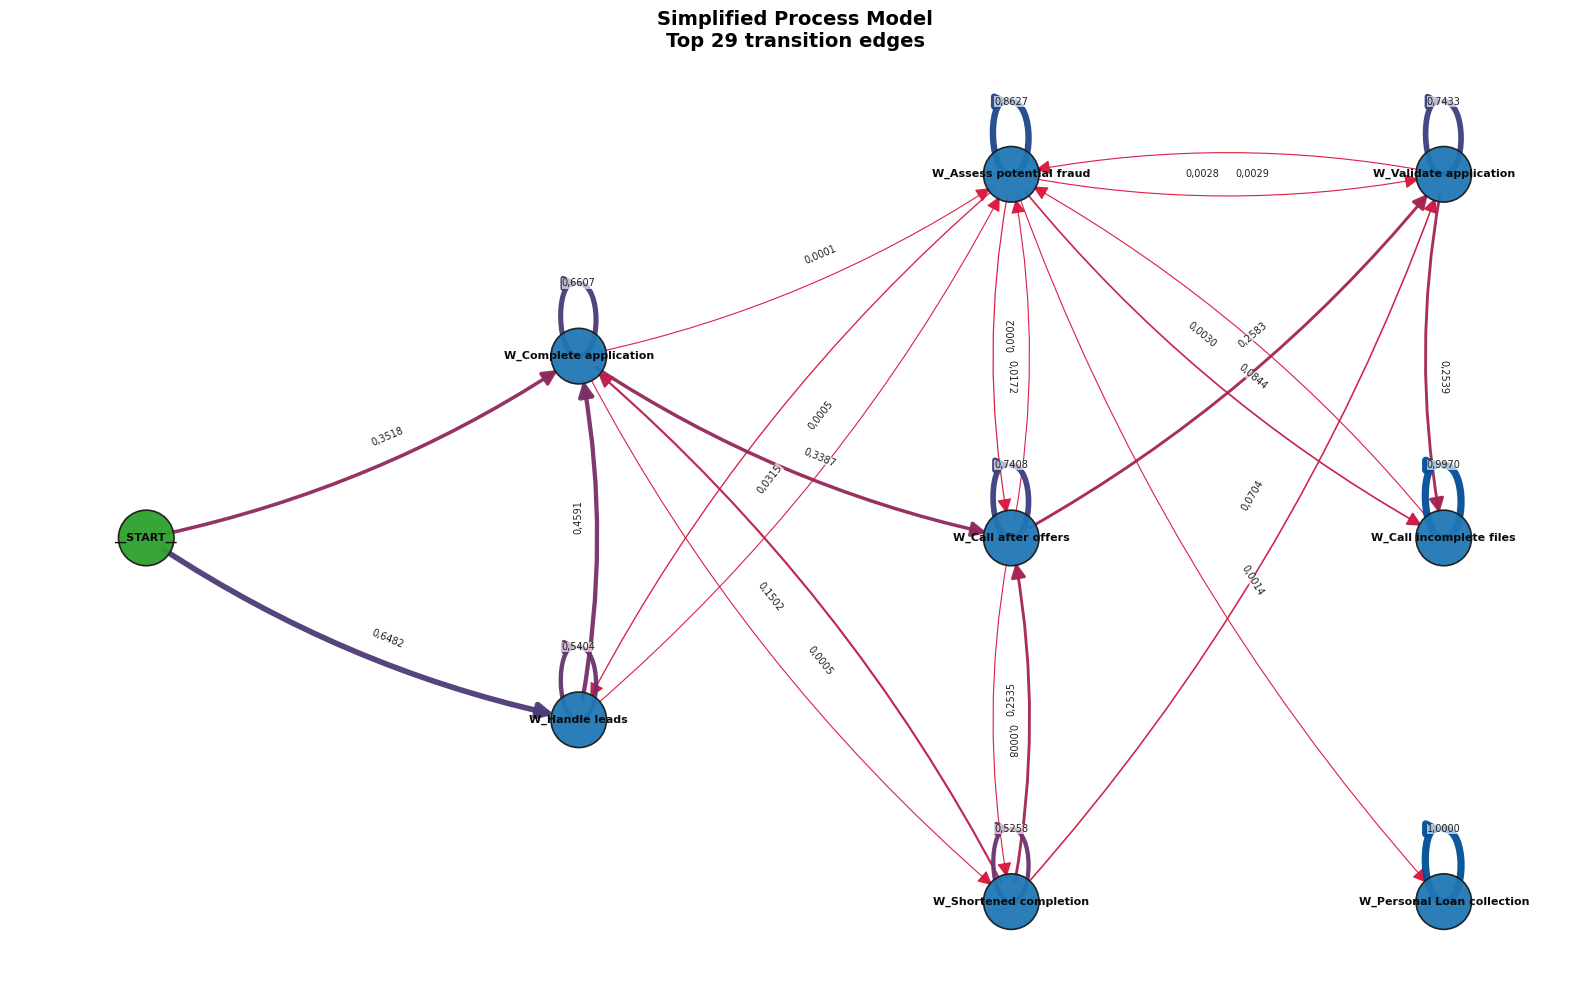

In [4]:
model = load_process_model()

# Print summary
print_model_summary(model)

# Visualize based on type
if isinstance(model, ProbabilisticProcessModel):
    visualize_probabilistic_model(
        model=model,
        show_top_n=50,
        min_probability=0.0001,
        include_start_node=True,
        figsize=(16, 10),
        layout="layered",
        spring_k_scale=8.5,
        spring_iterations=50,
    )
else:
    print(f"Unknown model type: {type(model)}")


In [5]:
# get process model metadata:
metadata = model.metadata
for attr in dir(metadata):
    if not attr.startswith("_"):
        print(f"{attr}: {getattr(metadata, attr)}")

activity_labels: ['W_Assess potential fraud', 'W_Call after offers', 'W_Call incomplete files', 'W_Complete application', 'W_Handle leads', 'W_Personal Loan collection', 'W_Shortened completion', 'W_Validate application']
categorical_attributes: []
categorical_values: {}
context_attributes: ['case:LoanGoal', 'case:ApplicationType']
feature_names: ['simple_transition_probabilities']
history_mode: None


In [6]:
import pm4py
import pandas as pd
# analyze xes file one process variants that only include W_ activities
filepath = proj_root / "data/historical_logs/BPIC17/BPI_Challenge_2017.xes"
log = pm4py.read_xes(str(filepath))
df = pm4py.convert_to_dataframe(log)
if 'time:timestamp' in df.columns:
        df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
        
df = df[df['concept:name'].str.startswith("W_")]
df['concept:name'] = df['concept:name'].str.strip()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_301/3764262769.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['concept:name'] = df['concept:name'].str.strip()


In [7]:
variants = pm4py.get_variants(df)

In [8]:
variant_data = []
for variant, count in variants.items():
    variant_str = " → ".join(variant)
    variant_data.append({
        'variant': variant_str,
        'count': count,
        'percentage': (count / len(log)) * 100,
        'length': len(variant)
    })

df = pd.DataFrame(variant_data).sort_values('count', ascending=False)

In [9]:
# change result column width to see full variant strings
pd.set_option('display.max_colwidth', None)
len(df)
print(df.head(20))
print(df['variant'].iloc[0])

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              variant  \
2                                                                                                                                                                                                                                                                                                                                                                        W_Complete application → W_Complete application → W_Complete applicati

In [10]:
# analyze the variants df with columns variant, count, percentage, length
all_variants_number = df["count"].sum()
print(f"Total number of cases in filtered log: {all_variants_number}")
variants_with_10_or_more = df[df["count"]>=5]
print(f"Number of variants with at least 10 cases: {len(variants_with_10_or_more)}")
cases_that_have_variants_with_10_or_more = variants_with_10_or_more["count"].sum()
print(f"Number of cases that have variants with at least 10 cases: {cases_that_have_variants_with_10_or_more} ({cases_that_have_variants_with_10_or_more/all_variants_number*100:.2f}%)")
variants_with_length_greater_than_5 = df[df["length"]>8]
print(f"Number of variants with length greater than 5: {len(variants_with_length_greater_than_5)} ({variants_with_length_greater_than_5['count'].sum()/all_variants_number*100:.2f}%)")
cases_that_have_variants_with_length_greater_than_5 = variants_with_length_greater_than_5["count"].sum()
print(f"Number of cases that have variants with length greater than 5: {cases_that_have_variants_with_length_greater_than_5} ({cases_that_have_variants_with_length_greater_than_5/all_variants_number*100:.2f}%)")

Total number of cases in filtered log: 31509
Number of variants with at least 10 cases: 643
Number of cases that have variants with at least 10 cases: 19473 (61.80%)
Number of variants with length greater than 5: 10678 (99.01%)
Number of cases that have variants with length greater than 5: 31196 (99.01%)


In [11]:
from collections import Counter, defaultdict
from itertools import combinations

# Extract capabilities
capabilities_data = []
for res in resources:
    caps = res.get('capabilities', [])
    if caps:  # Only include resources with capabilities
        capabilities_data.append({
            'id': res['id'],
            'name': res.get('name'),
            'role': res.get('role'),
            'capabilities': set(caps),
            'num_capabilities': len(caps)
        })

df = pd.DataFrame(capabilities_data)
print(f"Total resources with capabilities: {len(df)}")
print(f"Resources without capabilities: {len(resources) - len(df)}\n")

NameError: name 'resources' is not defined

In [ ]:
# 1. Capability frequency analysis
all_caps = []
for caps in df['capabilities']:
    all_caps.extend(caps)

cap_counts = Counter(all_caps)
print("=== Top 10 Most Common Capabilities ===")
for cap, count in cap_counts.most_common(10):
    print(f"{cap}: {count} resources ({count/len(df)*100:.1f}%)")

=== Top 10 Most Common Capabilities ===
W_Complete application: 117 resources (81.2%)
W_Validate application: 113 resources (78.5%)
W_Handle leads: 85 resources (59.0%)
W_Call after offers: 83 resources (57.6%)
W_Call incomplete files: 60 resources (41.7%)
W_Assess potential fraud: 32 resources (22.2%)


In [ ]:
# 2. Find capability co-occurrence patterns
print("\n=== Capability Co-occurrence Patterns ===")
print("(If capability A exists, how often does capability B also exist?)\n")

# Build co-occurrence matrix
cooccurrence = defaultdict(lambda: defaultdict(int))
for caps in df['capabilities']:
    caps_list = list(caps)
    for cap_a, cap_b in combinations(caps_list, 2):
        cooccurrence[cap_a][cap_b] += 1
        cooccurrence[cap_b][cap_a] += 1

# Find strong co-occurrence patterns (>80% co-occurrence)
patterns = []
for cap_a, cap_b_dict in cooccurrence.items():
    cap_a_total = cap_counts[cap_a]
    for cap_b, cooccur_count in cap_b_dict.items():
        if cap_a < cap_b:  # Avoid duplicates (A->B and B->A)
            percentage = (cooccur_count / cap_a_total) * 100
            if percentage >= 80:  # Strong correlation threshold
                patterns.append({
                    'cap_a': cap_a,
                    'cap_b': cap_b,
                    'cooccurrence': cooccur_count,
                    'cap_a_total': cap_a_total,
                    'percentage': percentage
                })

# Sort by percentage
patterns.sort(key=lambda x: x['percentage'], reverse=True)

print("Strong co-occurrence patterns (≥80%):")
for p in patterns[:20]:  # Top 20 patterns
    print(f"{p['cap_a']} → {p['cap_b']}: {p['cooccurrence']}/{p['cap_a_total']} ({p['percentage']:.1f}%)")



=== Capability Co-occurrence Patterns ===
(If capability A exists, how often does capability B also exist?)

Strong co-occurrence patterns (≥80%):
W_Call after offers → W_Complete application: 82/83 (98.8%)
W_Call incomplete files → W_Validate application: 59/60 (98.3%)
W_Assess potential fraud → W_Validate application: 29/32 (90.6%)
W_Call after offers → W_Validate application: 73/83 (88.0%)
W_Handle leads → W_Validate application: 69/85 (81.2%)


In [ ]:
# 3. Find exact capability sets (resources with identical capabilities)
print("\n=== Identical Capability Sets ===")
capability_sets = defaultdict(list)
for idx, row in df.iterrows():
    caps_tuple = tuple(sorted(row['capabilities']))
    capability_sets[caps_tuple].append(row['name'])

# Find sets with multiple resources
identical_sets = {k: v for k, v in capability_sets.items() if len(v) > 1}
print(f"Found {len(identical_sets)} capability sets shared by multiple resources\n")

for caps, resource_names in sorted(identical_sets.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
    print(f"\n{len(resource_names)} resources with identical capabilities:")
    print(f"  Capabilities: {', '.join(caps[:3])}..." if len(caps) > 3 else f"  Capabilities: {', '.join(caps)}")
    print(f"  Resources: {', '.join(resource_names[:5])}" + (f" and {len(resource_names)-5} more" if len(resource_names) > 5 else ""))



=== Identical Capability Sets ===
Found 16 capability sets shared by multiple resources


30 resources with identical capabilities:
  Capabilities: W_Call after offers, W_Complete application, W_Handle leads...
  Resources: Simon Müller, Marco Schmidt, David Müller, Ulrich Schmidt, Quinn Schmidt and 25 more

16 resources with identical capabilities:
  Capabilities: W_Call incomplete files, W_Validate application
  Resources: Nina Wagner, Paula Wagner, Marco Wagner, Oliver Wagner, Julia Wagner and 11 more

14 resources with identical capabilities:
  Capabilities: W_Assess potential fraud, W_Call after offers, W_Call incomplete files...
  Resources: Franziska Schmidt, Isabel Müller, Georg Weber, Vera Weber, Helena Weber and 9 more

13 resources with identical capabilities:
  Capabilities: W_Call after offers, W_Call incomplete files, W_Complete application...
  Resources: Simon Schmidt, Jakob Schmidt, Rosa Schmidt, David Schmidt, Christian Schmidt and 8 more

10 resources with identical

In [ ]:
# 4. Role-based capability analysis
print("\n=== Capabilities by Role ===")
role_caps = df.groupby('role')['capabilities'].apply(lambda x: set.union(*x) if len(x) > 0 else set())
for role, caps in role_caps.items():
    print(f"\n{role}: {len(caps)} unique capabilities")
    print(f"  {', '.join(sorted(caps)[:5])}" + ("..." if len(caps) > 5 else ""))


=== Capabilities by Role ===

Customer Service Representative: 4 unique capabilities
  W_Call after offers, W_Call incomplete files, W_Complete application, W_Validate application

Fraud Analyst: 6 unique capabilities
  W_Assess potential fraud, W_Call after offers, W_Call incomplete files, W_Complete application, W_Handle leads...

Loan Officer: 5 unique capabilities
  W_Call after offers, W_Call incomplete files, W_Complete application, W_Handle leads, W_Validate application

Sales Representative: 5 unique capabilities
  W_Call after offers, W_Call incomplete files, W_Complete application, W_Handle leads, W_Validate application

Senior Loan Officer: 5 unique capabilities
  W_Call after offers, W_Call incomplete files, W_Complete application, W_Handle leads, W_Validate application


In [ ]:
# 5. Distribution of capability set sizes
print("\n=== Capability Set Size Distribution ===")
size_dist = df['num_capabilities'].value_counts().sort_index()
for size, count in size_dist.items():
    print(f"{size} capabilities: {count} resources")


=== Capability Set Size Distribution ===
1 capabilities: 13 resources
2 capabilities: 30 resources
3 capabilities: 28 resources
4 capabilities: 38 resources
5 capabilities: 29 resources
6 capabilities: 6 resources
